In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    precision_recall_curve,
    average_precision_score
)

In [2]:
df = pd.read_csv(r"C:\Users\rakesh\Documents\SQL files\argo srs files\for predictions\listing_prediction_data.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   listing_id      88 non-null     int64  
 1   title           88 non-null     object 
 2   category        88 non-null     object 
 3   starting_value  88 non-null     float64
 4   num_bids        88 non-null     int64  
 5   final_price     87 non-null     float64
dtypes: float64(2), int64(2), object(2)
memory usage: 4.3+ KB


In [3]:
df.isnull().sum()

listing_id        0
title             0
category          0
starting_value    0
num_bids          0
final_price       1
dtype: int64

In [4]:
df = df.dropna(subset='final_price')

In [5]:
df['high_bid_count'] = (df['num_bids'] > 3).astype(int)

In [6]:
df['category'] = df['category'].astype('category')
df['category_encoded'] = df['category'].cat.codes

In [7]:
X = df[['starting_value', 'category_encoded']]
y = df['high_bid_count']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

In [9]:
model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [10]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

Accuracy: 0.5555555555555556
Precision: 0.3333333333333333
Recall: 0.3333333333333333


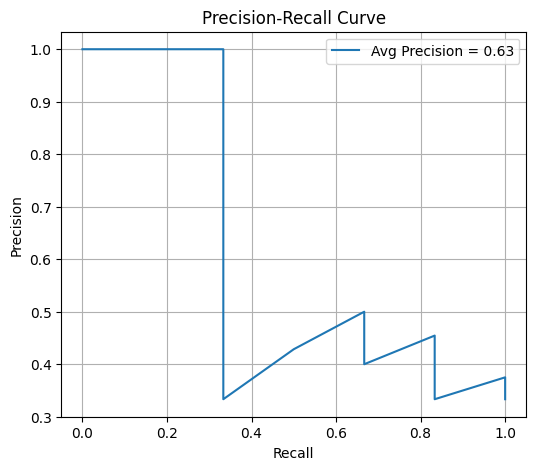

In [12]:
y_scores = model.predict_proba(X_test)[:, 1]

precision, recall, _ = precision_recall_curve(y_test, y_scores)
avg_precision = average_precision_score(y_test, y_scores)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'Avg Precision = {avg_precision:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()